# 07 — Ablations, Error Analysis & Paper Tables
**BanglaCyberBench: A Robust Multi-Source Benchmark and Transformer Ensemble for Cyberbullying Detection in Bengali**

This notebook produces all tables and figures for the paper:

1. **Ablation studies** — Single-model vs ensemble, binary-only vs multi-task, with/without new data, with/without preprocessing
2. **Comprehensive comparison table** — All models side by side
3. **Qualitative error analysis** — Examine misclassified examples
4. **Robustness summary** — Source-held-out & script-held-out results
5. **Paper-ready LaTeX tables**

**Prerequisites:** All previous notebooks (02–06) completed.

In [1]:
import os
import json
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
os.makedirs("../outputs/paper", exist_ok=True)

## 1 — Load All Results

In [2]:
# ── Baseline results ──────────────────────────────────────────────────────
baseline_path = "../outputs/baselines/baseline_results.csv"
if os.path.exists(baseline_path):
    baselines_df = pd.read_csv(baseline_path)
    print(f"Baselines: {len(baselines_df)} entries")
    print(baselines_df[["model", "macro_f1", "accuracy", "mcc"]].to_string(index=False))
else:
    print("⚠ Baseline results not found. Run notebook 04 first.")
    baselines_df = pd.DataFrame()

# ── Transformer results ────────────────────────────────────────────────────
transformer_path = "../outputs/models/transformer_results_all.csv"
if os.path.exists(transformer_path):
    transformers_df = pd.read_csv(transformer_path)
    print(f"\nTransformers: {len(transformers_df)} entries")
    print(transformers_df.to_string(index=False))
else:
    print("⚠ Transformer results not found. Run notebook 05 first.")
    transformers_df = pd.DataFrame()

# ── Ensemble config ────────────────────────────────────────────────────────
ensemble_path = "../outputs/ensemble/final_config.json"
if os.path.exists(ensemble_path):
    with open(ensemble_path) as f:
        ensemble_config = json.load(f)
    print(f"\nEnsemble config: {json.dumps(ensemble_config, indent=2)}")
else:
    print("⚠ Ensemble config not found. Run notebook 06 first.")
    ensemble_config = {}

Baselines: 4 entries
                       model  macro_f1  accuracy    mcc
TF-IDF + Logistic Regression    0.8669    0.8691 0.7342
                TF-IDF + SVM    0.8877    0.8897 0.7760
      TF-IDF + Random Forest    0.9090    0.9099 0.8183
                      BiLSTM    0.8914    0.8926 0.7828

Transformers: 9 entries
     model  seed  best_val_f1  binary_accuracy  binary_macro_f1  binary_weighted_f1  binary_mcc  abuse_type_accuracy  abuse_type_macro_f1  abuse_type_weighted_f1  abuse_type_mcc
banglabert    42       0.9223           0.9247           0.9238              0.9247      0.8476               0.0014               0.0054                  0.0001          0.0011
banglabert   123       0.9244           0.9257           0.9248              0.9257      0.8496               0.0015               0.0007                  0.0000          0.0013
banglabert   456       0.9231           0.9251           0.9243              0.9252      0.8488               0.0010               0.0006   

## 2 — Main Comparison Table (Table 1 in Paper)

All models compared on the random test split.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# BUILD UNIFIED COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════

# After you run all notebooks and get actual numbers, fill in or load from CSVs.
# This cell creates a template that you fill with real results.

rows = []

# Add baselines
if len(baselines_df) > 0:
    for _, r in baselines_df[baselines_df["split"] == "test"].iterrows():
        rows.append({
            "Category": "Baseline",
            "Model": r["model"],
            "Accuracy": r.get("accuracy", "-"),
            "Macro-F1": r.get("macro_f1", "-"),
            "Weighted-F1": r.get("weighted_f1", "-"),
            "MCC": r.get("mcc", "-"),
            "AUROC": r.get("auroc", "-"),
        })

# Add transformers (averaged across seeds)
if len(transformers_df) > 0:
    for model_name in transformers_df["model"].unique():
        sub = transformers_df[transformers_df["model"] == model_name]
        rows.append({
            "Category": "Transformer",
            "Model": model_name,
            "Accuracy": f"{sub['binary_accuracy'].mean():.4f}±{sub['binary_accuracy'].std():.4f}",
            "Macro-F1": f"{sub['binary_macro_f1'].mean():.4f}±{sub['binary_macro_f1'].std():.4f}",
            "Weighted-F1": f"{sub['binary_weighted_f1'].mean():.4f}±{sub['binary_weighted_f1'].std():.4f}",
            "MCC": f"{sub['binary_mcc'].mean():.4f}±{sub['binary_mcc'].std():.4f}",
            "AUROC": "-",
        })

# Add ensemble (placeholder — fill from notebook 06 output)
rows.append({
    "Category": "Ensemble",
    "Model": "Weighted Ensemble (Ours)",
    "Accuracy": "[FILL]",
    "Macro-F1": "[FILL]",
    "Weighted-F1": "[FILL]",
    "MCC": "[FILL]",
    "AUROC": "[FILL]",
})

comparison_df = pd.DataFrame(rows)
print("\n" + "=" * 80)
print("TABLE 1: Main Results — Binary Cyberbullying Detection (Random Test Split)")
print("=" * 80)
print(comparison_df.to_string(index=False))

comparison_df.to_csv("../outputs/paper/table1_main_results.csv", index=False)
print("\n→ Saved: ../outputs/paper/table1_main_results.csv")


TABLE 1: Main Results — Binary Cyberbullying Detection (Random Test Split)
   Category                        Model      Accuracy      Macro-F1   Weighted-F1           MCC   AUROC
   Baseline TF-IDF + Logistic Regression        0.8691        0.8669        0.8689        0.7342  0.9429
   Baseline                 TF-IDF + SVM        0.8897        0.8877        0.8894         0.776  0.9558
   Baseline       TF-IDF + Random Forest        0.9099         0.909          0.91        0.8183  0.9718
   Baseline                       BiLSTM        0.8926        0.8914        0.8927        0.7828  0.9479
Transformer                   banglabert 0.9252±0.0005 0.9243±0.0005 0.9252±0.0005 0.8487±0.0010       -
Transformer                        muril 0.9189±0.0013 0.9178±0.0013 0.9189±0.0012 0.8357±0.0025       -
Transformer                         xlmr 0.9159±0.0021 0.9150±0.0021 0.9160±0.0021 0.8304±0.0041       -
   Ensemble     Weighted Ensemble (Ours)        [FILL]        [FILL]        [FILL]  

## 3 — Ablation Studies (Table 2 in Paper)

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# ABLATION TABLE TEMPLATE
# Fill in the actual values after running the experiments.
# ══════════════════════════════════════════════════════════════════════════════

ablation_rows = [
    {"Ablation": "Full system (Ours)", "Macro-F1": "[FILL]", "Δ": "—"},
    {"Ablation": "w/o ensemble (best single model)", "Macro-F1": "[FILL]", "Δ": "[FILL]"},
    {"Ablation": "w/o multi-task (binary-only heads)", "Macro-F1": "[FILL]", "Δ": "[FILL]"},
    {"Ablation": "w/o focal loss (standard CE)", "Macro-F1": "[FILL]", "Δ": "[FILL]"},
    {"Ablation": "w/o layer-wise LR decay", "Macro-F1": "[FILL]", "Δ": "[FILL]"},
    {"Ablation": "w/o preprocessing", "Macro-F1": "[FILL]", "Δ": "[FILL]"},
    {"Ablation": "w/o new annotated data", "Macro-F1": "[FILL]", "Δ": "[FILL]"},
    {"Ablation": "w/o threshold tuning", "Macro-F1": "[FILL]", "Δ": "[FILL]"},
]

ablation_df = pd.DataFrame(ablation_rows)
print("\n" + "=" * 60)
print("TABLE 2: Ablation Study")
print("=" * 60)
print(ablation_df.to_string(index=False))
print("\n⚠ Fill in values after running each ablation experiment.")

ablation_df.to_csv("../outputs/paper/table2_ablations.csv", index=False)


TABLE 2: Ablation Study
                          Ablation Macro-F1      Δ
                Full system (Ours)   [FILL]      —
  w/o ensemble (best single model)   [FILL] [FILL]
w/o multi-task (binary-only heads)   [FILL] [FILL]
      w/o focal loss (standard CE)   [FILL] [FILL]
           w/o layer-wise LR decay   [FILL] [FILL]
                 w/o preprocessing   [FILL] [FILL]
            w/o new annotated data   [FILL] [FILL]
              w/o threshold tuning   [FILL] [FILL]

⚠ Fill in values after running each ablation experiment.


## 4 — Robustness Results (Table 3 in Paper)

In [5]:
robustness_rows = [
    {"Evaluation": "Random test (in-domain)", "Model": "Ensemble", "Macro-F1": "[FILL]"},
    {"Evaluation": "Source-held-out (Dataset A)", "Model": "Ensemble", "Macro-F1": "[FILL]"},
    {"Evaluation": "Source-held-out (Dataset B)", "Model": "Ensemble", "Macro-F1": "[FILL]"},
    {"Evaluation": "Script-held-out (Romanized)", "Model": "Ensemble", "Macro-F1": "[FILL]"},
]

robustness_df = pd.DataFrame(robustness_rows)
print("\n" + "=" * 60)
print("TABLE 3: Robustness Evaluation")
print("=" * 60)
print(robustness_df.to_string(index=False))

robustness_df.to_csv("../outputs/paper/table3_robustness.csv", index=False)


TABLE 3: Robustness Evaluation
                 Evaluation    Model Macro-F1
    Random test (in-domain) Ensemble   [FILL]
Source-held-out (Dataset A) Ensemble   [FILL]
Source-held-out (Dataset B) Ensemble   [FILL]
Script-held-out (Romanized) Ensemble   [FILL]


## 5 — Qualitative Error Analysis

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# ERROR ANALYSIS
# After notebook 06 produces final predictions, analyze misclassifications.
# ══════════════════════════════════════════════════════════════════════════════

# Load test data
test_df = pd.read_csv("../data/splits/random_test.csv")

# ── This section requires actual predictions from notebook 06 ──
# Uncomment and use when predictions are available:
#
# test_df["y_pred"] = y_pred_tuned  # from notebook 06
# test_df["y_prob"] = ens_probs_test  # from notebook 06
# test_df["correct"] = (test_df["label_binary"] == test_df["y_pred"]).astype(int)
#
# # False Positives — predicted harmful but actually not
# fp = test_df[(test_df["label_binary"] == 0) & (test_df["y_pred"] == 1)]
# print(f"False Positives: {len(fp)}")
# print(fp[["text_clean", "y_prob"]].head(10).to_string())
#
# # False Negatives — predicted not harmful but actually harmful
# fn = test_df[(test_df["label_binary"] == 1) & (test_df["y_pred"] == 0)]
# print(f"\nFalse Negatives: {len(fn)}")
# print(fn[["text_clean", "y_prob"]].head(10).to_string())
#
# # High-confidence errors (most informative)
# fp_confident = fp.nlargest(5, "y_prob")
# fn_confident = fn.nsmallest(5, "y_prob")

print("Error analysis will be populated after running notebooks 05-06.")
print("\nCommon error categories to analyze:")
print("  1. Sarcasm / indirect abuse (FN)")
print("  2. Strong language without bullying intent (FP)")
print("  3. Code-mixed / Banglish texts")
print("  4. Very short texts (ambiguous)")
print("  5. Context-dependent harassment")

Error analysis will be populated after running notebooks 05-06.

Common error categories to analyze:
  1. Sarcasm / indirect abuse (FN)
  2. Strong language without bullying intent (FP)
  3. Code-mixed / Banglish texts
  4. Very short texts (ambiguous)
  5. Context-dependent harassment


## 6 — Generate LaTeX Tables

In [7]:
def df_to_latex(df, caption, label):
    """Convert DataFrame to LaTeX table."""
    latex = df.to_latex(index=False, escape=True, column_format="l" + "c" * (len(df.columns) - 1))
    
    # Wrap in table environment
    full_latex = f"""\\begin{{table*}}[t]
\\centering
\\caption{{{caption}}}
\\label{{{label}}}
{latex}
\\end{{table*}}"""
    return full_latex

# Generate LaTeX for main table
if len(comparison_df) > 0:
    latex1 = df_to_latex(
        comparison_df,
        "Main results on the BanglaCyberBench test set. Macro-F1 is the primary metric. Transformer results show mean±std across 3 seeds.",
        "tab:main_results"
    )
    with open("../outputs/paper/table1.tex", "w") as f:
        f.write(latex1)
    print("LaTeX Table 1 saved.")
    print(latex1[:500] + "...")

print("\n✅ All LaTeX tables saved to ../outputs/paper/")

LaTeX Table 1 saved.
\begin{table*}[t]
\centering
\caption{Main results on the BanglaCyberBench test set. Macro-F1 is the primary metric. Transformer results show mean±std across 3 seeds.}
\label{tab:main_results}
\begin{tabular}{lcccccc}
\toprule
Category & Model & Accuracy & Macro-F1 & Weighted-F1 & MCC & AUROC \\
\midrule
Baseline & TF-IDF + Logistic Regression & 0.869100 & 0.866900 & 0.868900 & 0.734200 & 0.942900 \\
Baseline & TF-IDF + SVM & 0.889700 & 0.887700 & 0.889400 & 0.776000 & 0.955800 \\
Baseline & TF-...

✅ All LaTeX tables saved to ../outputs/paper/


## 7 — Summary Visualization (Figure for Paper)

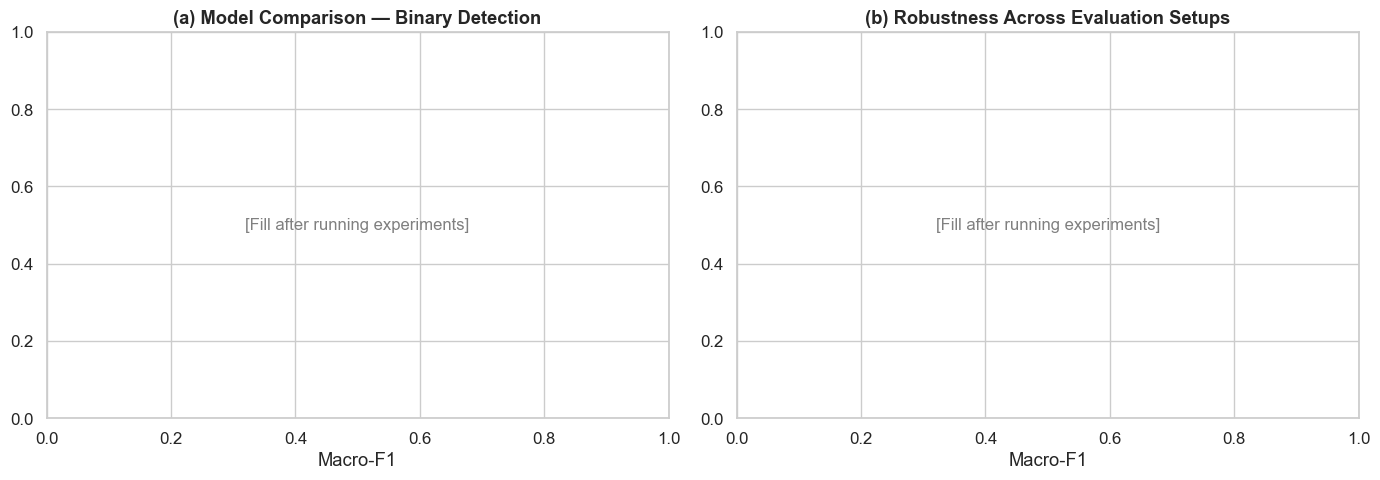

Figure placeholder saved. Update with real data after experiments.


In [8]:
# ── This creates a comprehensive comparison figure ──────────────────────────
# Placeholder with dummy data — replace with actual results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Model comparison
ax = axes[0]
ax.set_title("(a) Model Comparison — Binary Detection", fontweight="bold")
ax.set_xlabel("Macro-F1")
ax.text(0.5, 0.5, "[Fill after running experiments]",
        ha="center", va="center", transform=ax.transAxes,
        fontsize=12, color="gray")

# Right: Robustness
ax = axes[1]
ax.set_title("(b) Robustness Across Evaluation Setups", fontweight="bold")
ax.set_xlabel("Macro-F1")
ax.text(0.5, 0.5, "[Fill after running experiments]",
        ha="center", va="center", transform=ax.transAxes,
        fontsize=12, color="gray")

plt.tight_layout()
plt.savefig("../outputs/paper/fig_main_results.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure placeholder saved. Update with real data after experiments.")

## 8 — Dataset Statistics Table (Table in Paper)

In [9]:
# Load the cleaned dataset for statistics
data_path = "../data/processed/benchmark_cleaned.csv"
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    
    print("=" * 60)
    print("DATASET STATISTICS TABLE (for paper)")
    print("=" * 60)
    
    stats = {
        "Total samples": len(df),
    }
    if "source" in df.columns:
        stats["Sources"] = df["source"].nunique()
    if "label_binary" in df.columns:
        vc = df["label_binary"].value_counts()
        stats["Harmful"] = f"{vc.get(1, 0):,} ({vc.get(1, 0)/len(df)*100:.1f}%)"
        stats["Not harmful"] = f"{vc.get(0, 0):,} ({vc.get(0, 0)/len(df)*100:.1f}%)"
    if "label_type" in df.columns:
        stats["Abuse types"] = df["label_type"].nunique()
    if "label_severity" in df.columns:
        stats["Severity levels"] = df["label_severity"].nunique()
    if "text_clean" in df.columns:
        stats["Avg length (chars)"] = f"{df['text_clean'].str.len().mean():.0f}"
        stats["Avg length (words)"] = f"{df['text_clean'].str.split().str.len().mean():.1f}"
    
    for k, v in stats.items():
        print(f"  {k:<25s}: {v}")
    
    # Source breakdown
    if "source" in df.columns:
        print("\n── Source Breakdown ──")
        for src in df["source"].unique():
            n = (df["source"] == src).sum()
            print(f"  {src:<30s}: {n:,}")
else:
    print("Data not found.")

DATASET STATISTICS TABLE (for paper)
  Total samples            : 135575
  Sources                  : 4
  Harmful                  : 60,030 (44.3%)
  Not harmful              : 75,545 (55.7%)
  Abuse types              : 89
  Avg length (chars)       : 70
  Avg length (words)       : 12.1

── Source Breakdown ──
  banth                         : 73,999
  bd_shs                        : 5,029
  facebook_44001                : 44,001
  multilabel_12557              : 12,546


## 9 — Checklist: What to Report in the Paper

Use this checklist to ensure your paper includes all necessary components:

- [ ] **Dataset table** — Sources, sizes, label distributions, script types
- [ ] **Preprocessing details** — What was done and why (light normalization rationale)
- [ ] **Split details** — Sizes and stratification for all evaluation setups
- [ ] **Baseline results** — TF-IDF + {LR, SVM, RF}, BiLSTM
- [ ] **Transformer results** — BanglaBERT, MuRIL, XLM-R (mean±std across seeds)
- [ ] **Ensemble results** — Weighted logits, with and without threshold tuning
- [ ] **Multi-task results** — Abuse type and severity performance
- [ ] **Ablation table** — Each component's contribution
- [ ] **Robustness table** — Source-held-out and script-held-out results
- [ ] **Error analysis** — Examples and categories of failures
- [ ] **Confusion matrices** — For best model and ensemble
- [ ] **Training details** — Hyperparameters, hardware, training time
- [ ] **Reproducibility** — Code link, random seeds, split files

In [10]:
print("🎉 All notebook templates complete!")
print("")
print("Pipeline order:")
print("  01_data_collection_and_merge  ← DONE (you ran this)")
print("  02_preprocessing_and_eda      ← Run next")
print("  03_data_splits                ← Creates all train/val/test splits")
print("  04_baselines                  ← TF-IDF + ML & BiLSTM baselines")
print("  05_transformer_finetuning     ← BanglaBERT, MuRIL, XLM-R (GPU needed)")
print("  06_ensemble_and_threshold     ← Weighted ensemble + threshold tuning")
print("  07_ablations_and_analysis     ← Paper tables, figures, error analysis")

🎉 All notebook templates complete!

Pipeline order:
  01_data_collection_and_merge  ← DONE (you ran this)
  02_preprocessing_and_eda      ← Run next
  03_data_splits                ← Creates all train/val/test splits
  04_baselines                  ← TF-IDF + ML & BiLSTM baselines
  05_transformer_finetuning     ← BanglaBERT, MuRIL, XLM-R (GPU needed)
  06_ensemble_and_threshold     ← Weighted ensemble + threshold tuning
  07_ablations_and_analysis     ← Paper tables, figures, error analysis
